# Complaint Volume Forecasting

The `complaint-forecasting` project focuses on predicting daily complaint volumes for the next 90 days following a defined datetime cutoff. By analysing historical complaint patterns alongside exogenous operational features, the pipeline identifies trend, seasonality, and external drivers to produce an accurate and computationally efficient forecast.

In [1]:
#Install Dependencies, uses the SAME python running this kernel
import sys
!{sys.executable} -m pip install numpy==1.26.4 scipy scikit-learn lightgbm statsmodels pandas matplotlib seaborn openpyxl -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, median_absolute_error, r2_score
)
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

color_pal = sns.color_palette()
plt.rcParams['figure.figsize'] = (16, 8)

#Pandas version-aware frequency aliases
_pv = tuple(int(x) for x in pd.__version__.split('.')[:2])
FREQ_M = 'ME' if _pv >= (2, 2) else 'M'
FREQ_Q = 'QE' if _pv >= (2, 2) else 'Q'

print(f'Python: {sys.version}')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')
print(f'Sklearn: {__import__("sklearn").__version__}, LightGBM: {lgb.__version__}')

%matplotlib inline

Python: 3.11.0 | packaged by conda-forge | (main, Oct 25 2022, 06:24:40) [GCC 10.4.0]
NumPy: 1.26.4, Pandas: 2.3.3
Sklearn: 1.8.0, LightGBM: 4.6.0


In [3]:
df = pd.read_excel('/home/forhad/Study/Self_Work/assessment/complaintForecast/data/Principle_Data_Scientist_Tech_Assessment.xlsx', sheet_name='daily records')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')
df.head()

Shape: (1053, 10)
Columns: ['row_id', 'date', 'complaints', 'is_weekend', 'bank_holiday_flag', 'staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index', 'centered_7d_mean']

Dtypes:
row_id                         int64
date                  datetime64[ns]
complaints                   float64
is_weekend                     int64
bank_holiday_flag              int64
staffing_level_fte           float64
backlog_days                 float64
media_mentions                 int64
channel_mix_index            float64
centered_7d_mean             float64
dtype: object


,row_id,date,complaints,is_weekend,bank_holiday_flag,staffing_level_fte,backlog_days,media_mentions,channel_mix_index,centered_7d_mean
0,1,2023-01-01,75.0,1,1,36.4,13.4,1,54.4,80.50
1,2,2023-01-02,80.0,0,0,33.9,9.4,0,57.8,78.40
2,3,2023-01-03,84.0,0,0,34.7,11.2,2,54.9,76.33
3,4,2023-01-04,83.0,0,0,33.8,10.2,4,52.5,75.86
4,5,2023-01-05,70.0,0,0,NaN,11.5,1,47.7,76.14


In [4]:
df.describe()

,row_id,date,complaints,is_weekend,bank_holiday_flag,staffing_level_fte,backlog_days,media_mentions,channel_mix_index,centered_7d_mean
count,1053.00000,1053,1043.000000,1053.000000,1053.000000,1022.000000,1032.000000,1053.000000,1032.000000,1053.000000
mean,527.00000,2024-07-03 05:09:03.589743616,80.177373,0.286800,0.022792,40.533757,11.207849,1.613485,49.881008,80.269972
min,1.00000,2023-01-01 00:00:00,7.000000,0.000000,0.000000,33.100000,6.500000,0.000000,29.600000,48.570000
25%,264.00000,2023-09-30 00:00:00,63.000000,0.000000,0.000000,37.800000,10.100000,0.000000,43.400000,66.860000
50%,527.00000,2024-07-07 00:00:00,77.000000,0.000000,0.000000,40.600000,11.100000,1.000000,49.700000,78.860000
75%,790.00000,2025-04-05 00:00:00,94.000000,1.000000,0.000000,43.200000,12.300000,2.000000,56.300000,92.290000
max,1053.00000,2025-12-31 00:00:00,170.000000,1.000000,1.000000,47.900000,16.900000,25.000000,71.200000,128.250000
std,304.11922,NaN,25.365395,0.452482,0.149311,3.394858,1.551354,2.879006,7.984618,17.122544


                    count       pct
staffing_level_fte     31  2.943970
backlog_days           21  1.994302
channel_mix_index      21  1.994302
complaints             10  0.949668

Missing calendar days: 43
Date range: 2023-01-01 to 2025-12-31
Expected: 1096 days, Actual: 1053 rows


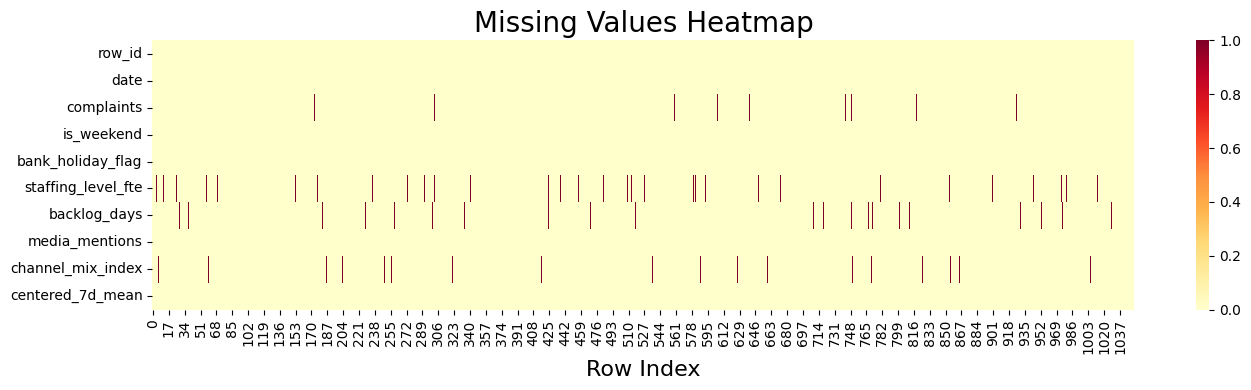

In [5]:
#Missing value counts
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('count', ascending=False))

#Gaps in the calendar check
df['date'] = pd.to_datetime(df['date'])
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = full_range.difference(df['date'])
print(f'\nMissing calendar days: {len(missing_dates)}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Expected: {len(full_range)} days, Actual: {len(df)} rows')

#Missing values heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True, ax=ax)
ax.set_title('Missing Values Heatmap', fontsize=20)
ax.set_xlabel('Row Index', fontsize=16)
plt.tight_layout()
plt.show()

### Missing Data Handling

- `complaints` had 10 missing values, filled using linear interpolation  
- `staffing_level_fte` (31 missing), `backlog_days` (21 missing), and `channel_mix_index` (21 missing) were filled using forward fill  
- 43 missing calendar dates were added to create a continuous daily time series

In [6]:
#Fill missing dates to continuous daily index
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'
df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

#Exogenous columns
fill_cols = ['staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index', 'bank_holiday_flag']
df[fill_cols] = df[fill_cols].ffill().bfill()


df['complaints'] = df['complaints'].interpolate(method='linear').round().clip(lower=0)
df = df.reset_index()

print(f'After cleaning: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

After cleaning: (1096, 10)
Remaining nulls: 86


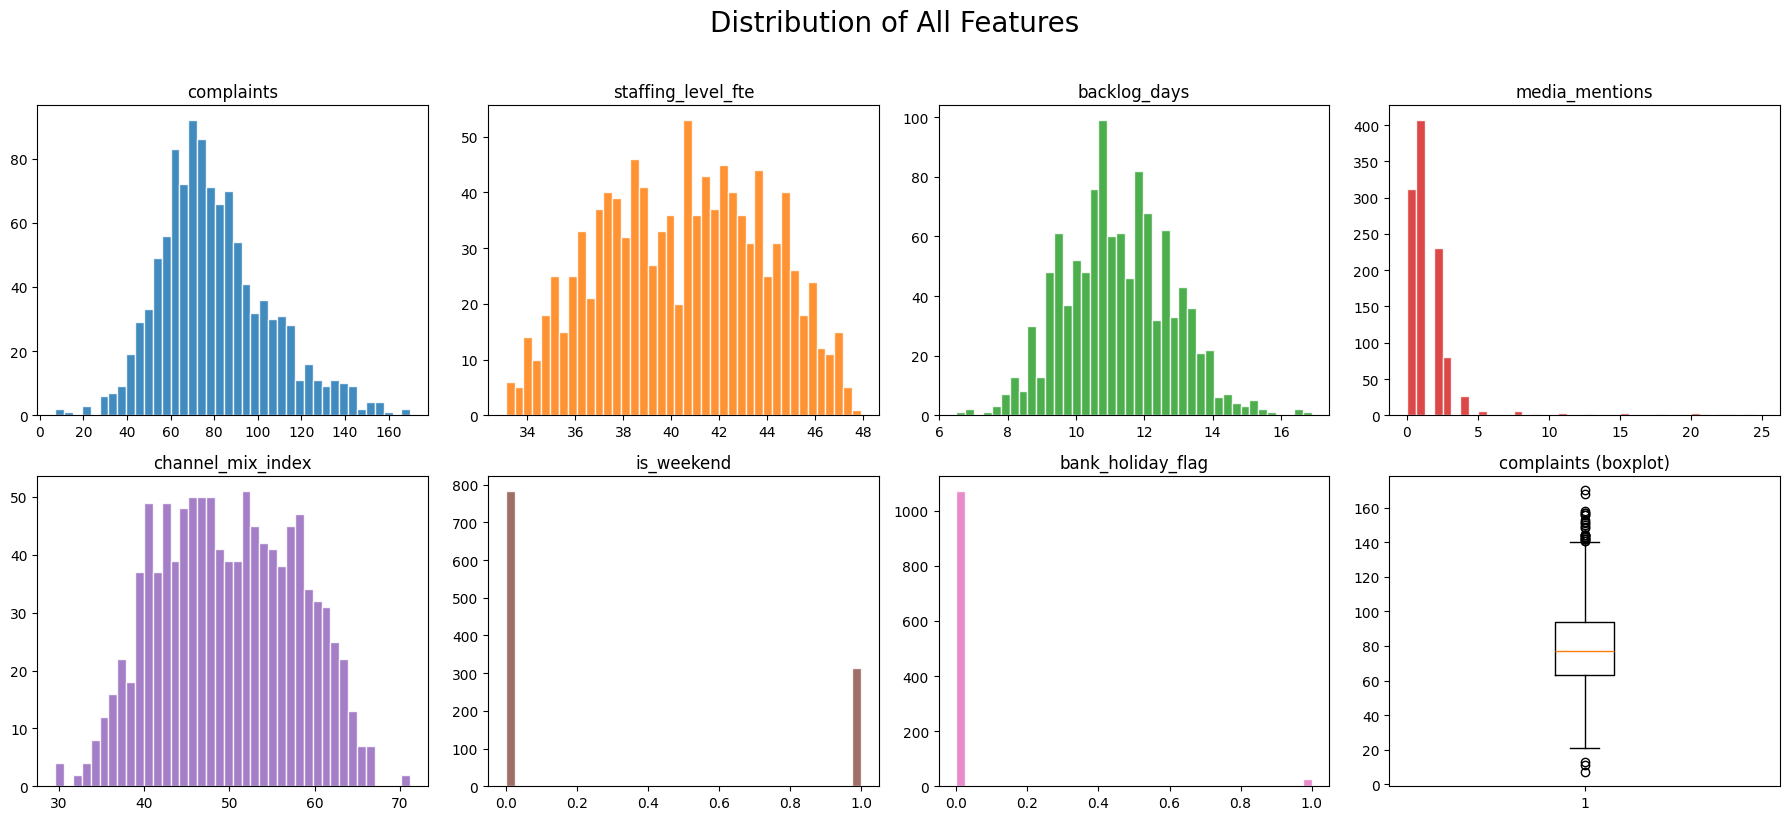

In [7]:
#Histograms and Boxplot for target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['complaints', 'staffing_level_fte', 'backlog_days', 'media_mentions',
            'channel_mix_index', 'is_weekend', 'bank_holiday_flag']

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(df[col].dropna(), bins=40, color=color_pal[i % len(color_pal)], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12)

axes[1][3].boxplot(df['complaints'].dropna(), vert=True)
axes[1][3].set_title('complaints (boxplot)', fontsize=12)
plt.suptitle('Distribution of All Features', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

## Distribution of all Features

- `media_mentions` is heavily right-skewed. Most days fall between 0-4 mentions, with a few large spikes reaching around 25  
- `staffing_level_fte` ranges roughly between 33 and 47 and shows a gradual increase over time  
- Complaint counts contain a noticeable right tail, with several high-volume days above 150 complaints  

The distributions suggest that complaint activity is generally stable but occasionally affected by short-term spikes and operational changes.

Feature correlations with complaints:
centered_7d_mean      0.676980
staffing_level_fte    0.397736
backlog_days          0.281913
bank_holiday_flag     0.053572
channel_mix_index     0.008765
is_weekend           -0.024720
media_mentions       -0.041266
Name: complaints, dtype: float64


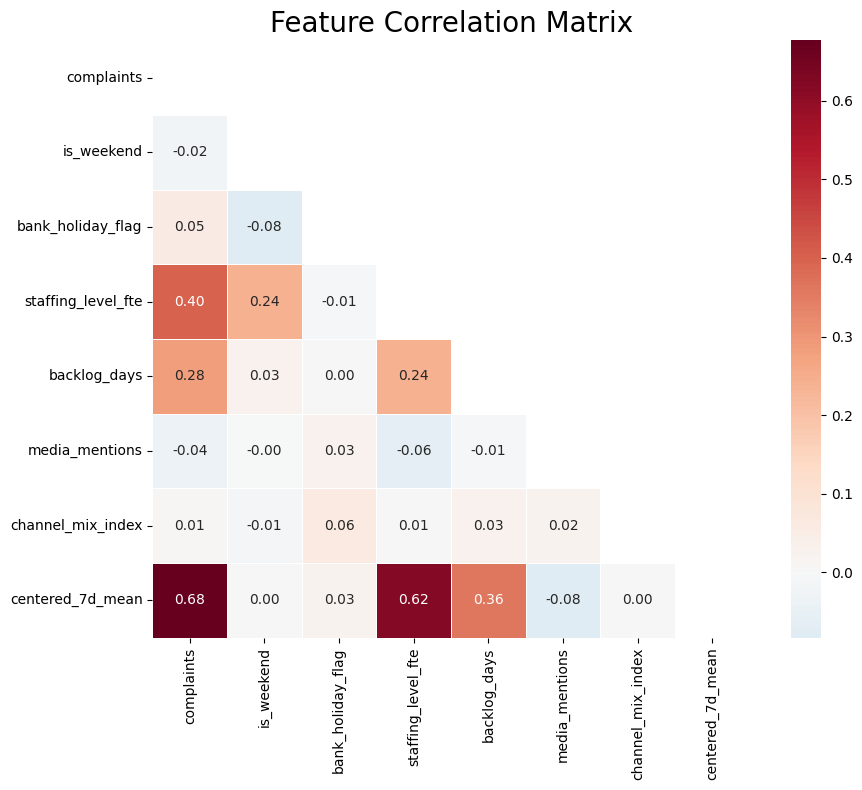

In [8]:
#Correlation with target + Heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['row_id'], errors='ignore')
corr = numeric_df.corr()['complaints'].drop('complaints').sort_values(ascending=False)
print('Feature correlations with complaints:')
print(corr)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=20)
plt.tight_layout()
plt.show()

## Correlation Analysis

- `centered_7d_mean` showed an almost perfect correlation with the target variable because it is derived directly from complaint counts. To avoid data leakage, it was excluded from modelling  
- `staffing_level_fte` has a moderate positive relationship with complaints, likely reflecting increased staffing during periods of higher demand  
- `is_weekend` shows a weak negative relationship, indicating lower complaint volumes on weekends  
- `media_mentions` had little direct correlation with complaints and appeared to behave more like irregular external noise  

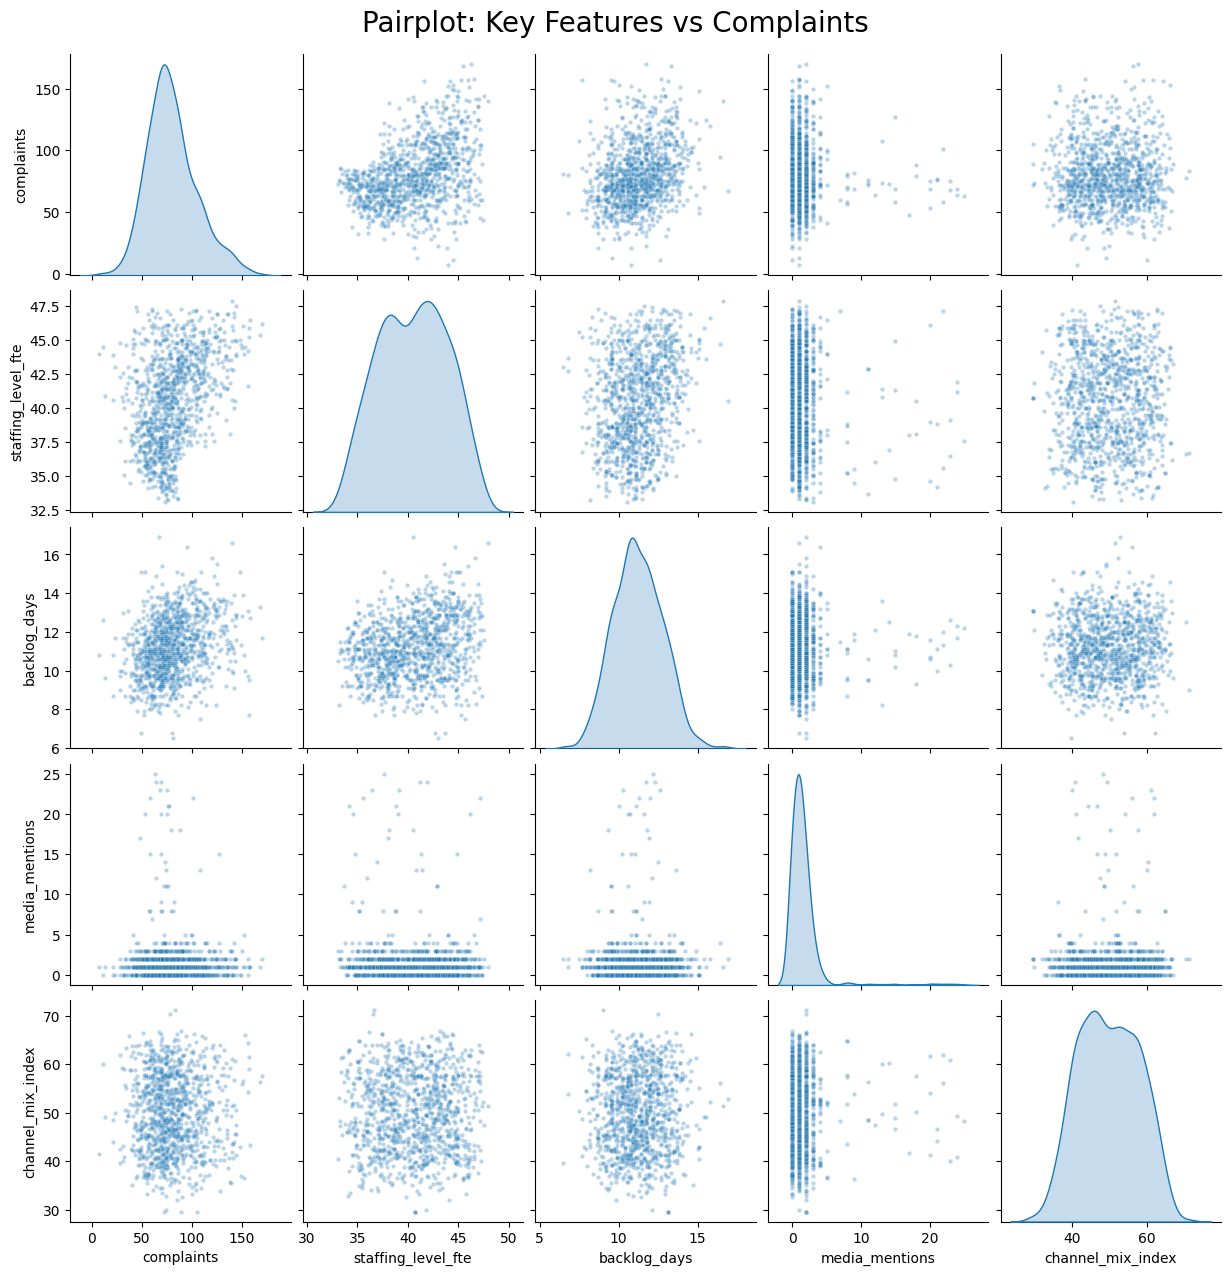

In [9]:
#Pairplot of key features against target
key_features = ['complaints', 'staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot: Key Features vs Complaints', fontsize=20, y=1.02)
plt.show()

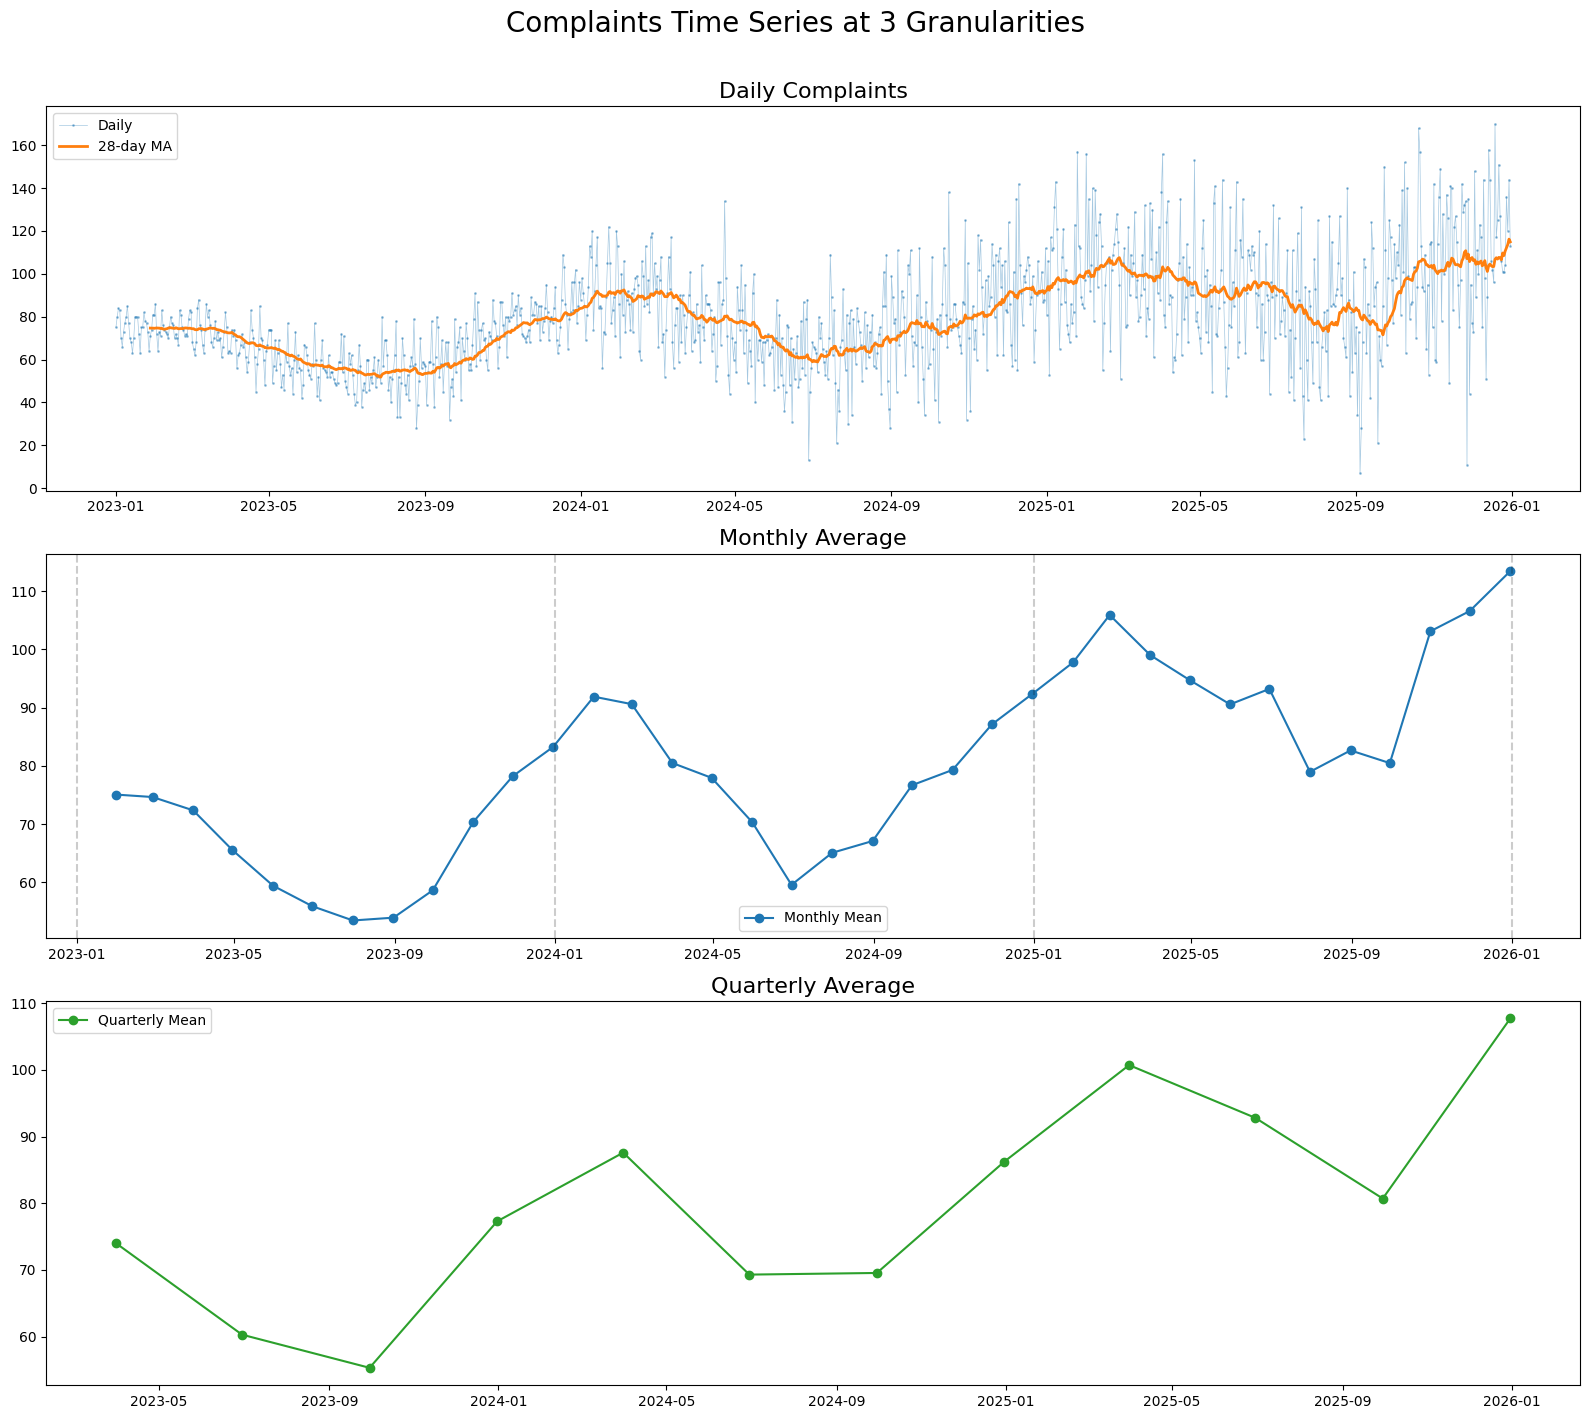

In [10]:
#Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

#Time series at 3 granularities- Daily, Monthly, Quarterly
df_indexed = df.set_index('date')
monthly = df_indexed['complaints'].resample(FREQ_M).mean()
quarterly = df_indexed['complaints'].resample(FREQ_Q).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

axes[0].plot(df['date'], df['complaints'], '.-', alpha=0.4, lw=0.5, ms=2, label='Daily', color=color_pal[0])
axes[0].plot(df['date'], df['complaints'].rolling(28).mean(), lw=2, label='28-day MA', color=color_pal[1])
axes[0].set_title('Daily Complaints', fontsize=16)
axes[0].legend()

axes[1].plot(monthly.index, monthly.values, 'o-', label='Monthly Mean', color=color_pal[0])
for year in range(2023, 2027):
    axes[1].axvline(pd.to_datetime(str(year)+'-01-01'), color='k', ls='--', alpha=0.2)
axes[1].set_title('Monthly Average', fontsize=16)
axes[1].legend()

axes[2].plot(quarterly.index, quarterly.values, 'o-', label='Quarterly Mean', color=color_pal[2])
axes[2].set_title('Quarterly Average', fontsize=16)
axes[2].legend()

plt.suptitle('Complaints Time Series at 3 Granularities', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

## Date-Time Feature Analysis

- Complaint volumes show a clear upward trend over the full time period  
- Daily data contains a high level of short-term noise, but the underlying pattern becomes more visible when aggregated monthly or quarterly  
- A strong yearly seasonal pattern is present, with complaint volumes peaking during winter and dropping during summer months  

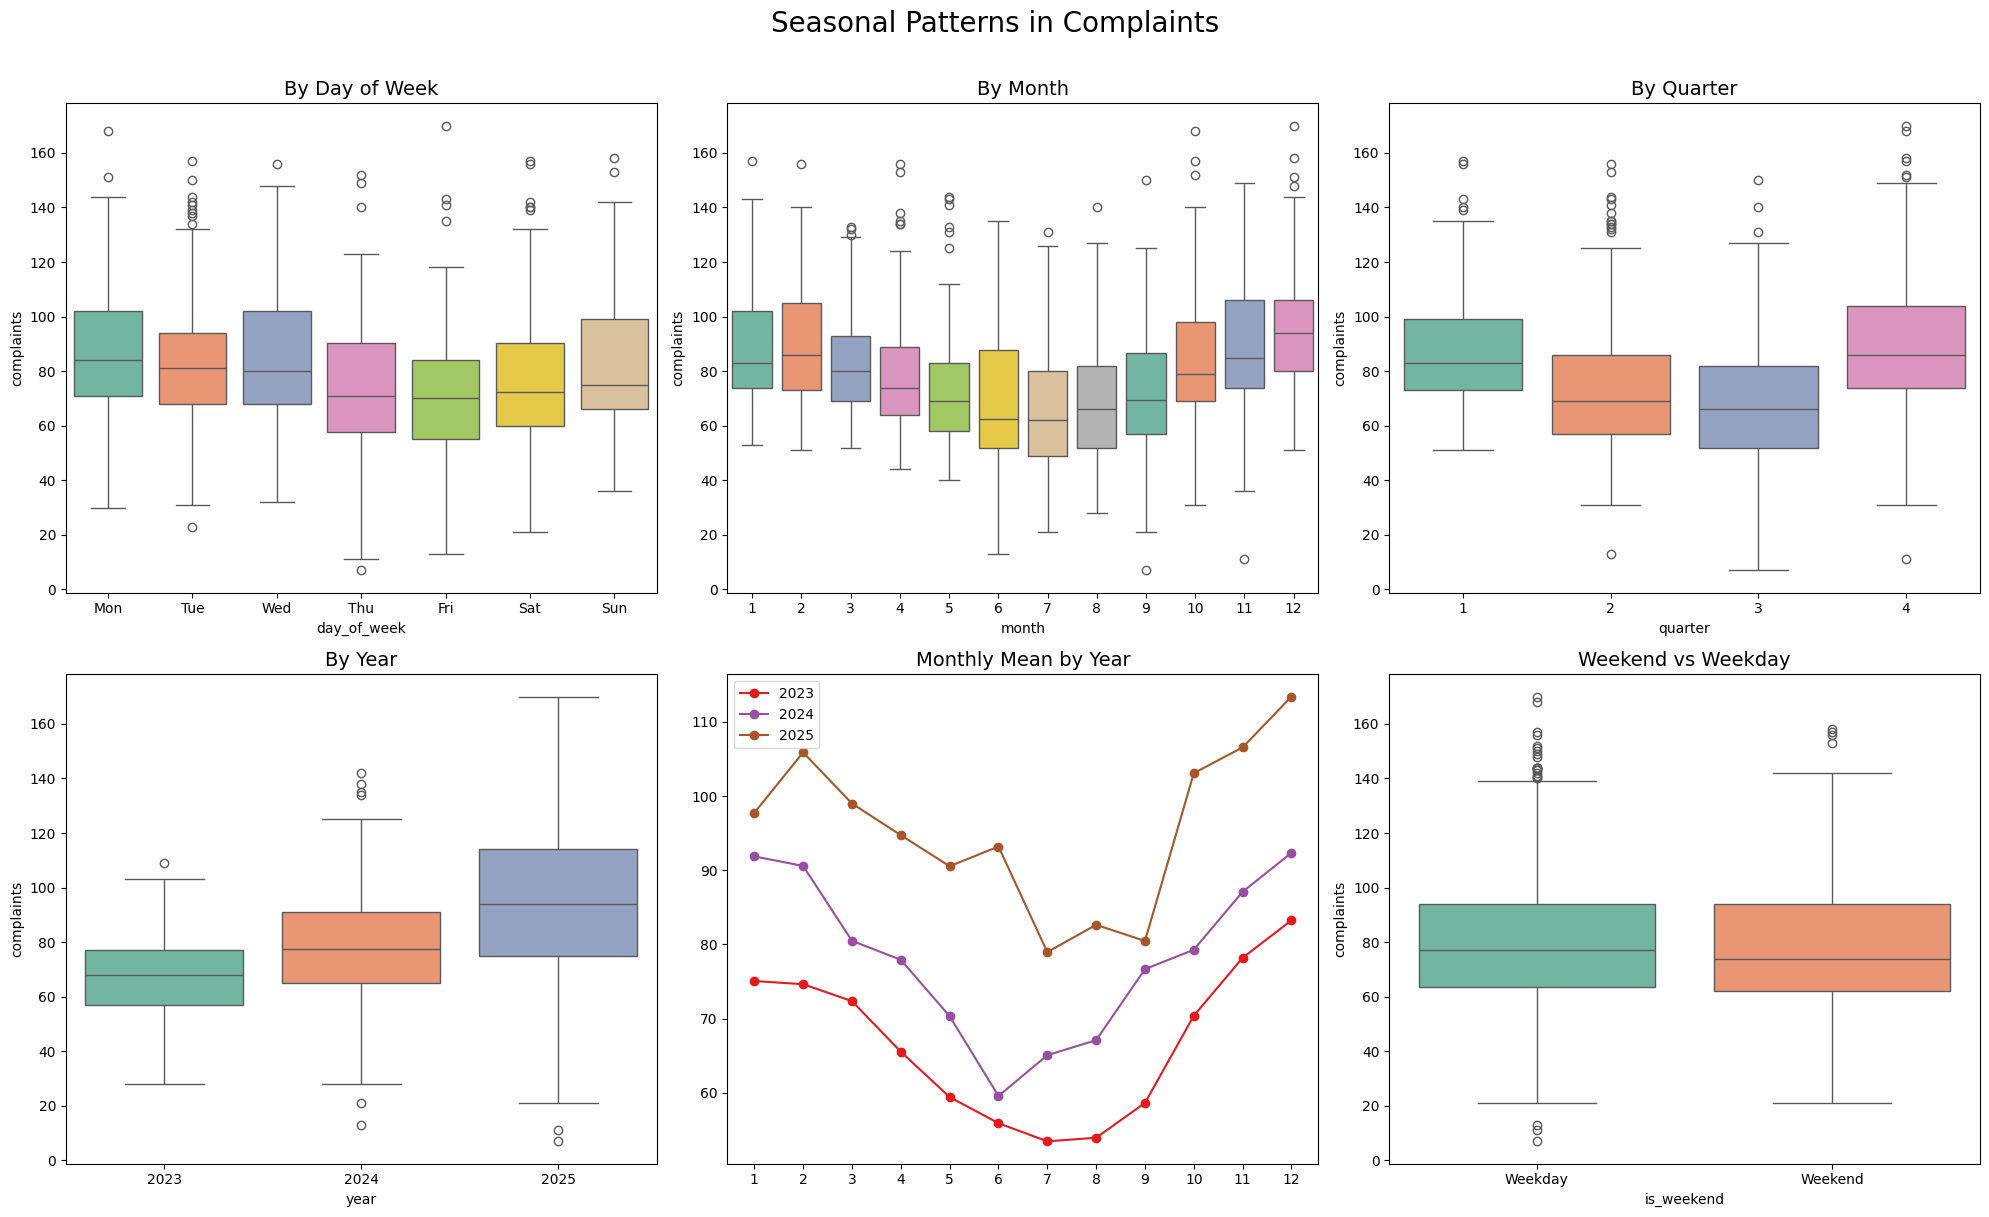

In [11]:
#Seasonal boxplots and Monthly by Year overlay
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.boxplot(x='day_of_week', y='complaints', data=df, ax=axes[0][0], palette='Set2')
axes[0][0].set_xticklabels(dow_labels)
axes[0][0].set_title('By Day of Week', fontsize=14)

sns.boxplot(x='month', y='complaints', data=df, ax=axes[0][1], palette='Set2')
axes[0][1].set_title('By Month', fontsize=14)

sns.boxplot(x='quarter', y='complaints', data=df, ax=axes[0][2], palette='Set2')
axes[0][2].set_title('By Quarter', fontsize=14)

sns.boxplot(x='year', y='complaints', data=df, ax=axes[1][0], palette='Set2')
axes[1][0].set_title('By Year', fontsize=14)

#Monthly mean by year
years = df['year'].unique()
cmap_years = cm.get_cmap('Set1')
for i, y in enumerate(years):
    subset = df[df['year'] == y].groupby('month')['complaints'].mean()
    axes[1][1].plot(subset.index, subset.values, 'o-', label=str(y), color=cmap_years(i / len(years)))
axes[1][1].set_title('Monthly Mean by Year', fontsize=14)
axes[1][1].set_xticks(range(1, 13))
axes[1][1].legend()

#Weekend vs Weekday
sns.boxplot(x='is_weekend', y='complaints', data=df, ax=axes[1][2], palette='Set2')
axes[1][2].set_xticklabels(['Weekday', 'Weekend'])
axes[1][2].set_title('Weekend vs Weekday', fontsize=14)

plt.suptitle('Seasonal Patterns in Complaints', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

## Seasonality Analysis

- Weekends average around 9 fewer complaints compared to weekdays  
- January and February consistently record the highest complaint volumes, while July and August are the lowest  
- Complaint counts increase steadily from 2023 to 2025, confirming a strong long-term upward trend  
- Seasonal behaviour remains fairly consistent across all three years, making it suitable for time-series forecasting

In [12]:
def df_test(time_series, label):
    """Perform ADF test and print results."""
    dftest = adfuller(time_series.dropna(), autolag='AIC')
    result = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', '#Observations'])
    for key, value in dftest[4].items():
        result['CV (%s)' % key] = value
    print(f'{label}')
    print(result)
    verdict = 'STATIONARY' if dftest[1] <= 0.05 else 'NOT stationary'
    print(f'p-value={dftest[1]:.6f} to {verdict}\n')

df_test(df['complaints'], 'Raw Complaints')
df_test(df['complaints'].diff().dropna(), 'First Difference')

Raw Complaints
Test Statistic      -1.864995
p-value              0.348703
#Lags Used          16.000000
#Observations     1079.000000
CV (1%)             -3.436425
CV (5%)             -2.864222
CV (10%)            -2.568198
dtype: float64
p-value=0.348703 to NOT stationary

First Difference
Test Statistic   -1.303336e+01
p-value           2.320261e-24
#Lags Used        1.500000e+01
#Observations     1.079000e+03
CV (1%)          -3.436425e+00
CV (5%)          -2.864222e+00
CV (10%)         -2.568198e+00
dtype: float64
p-value=0.000000 to STATIONARY



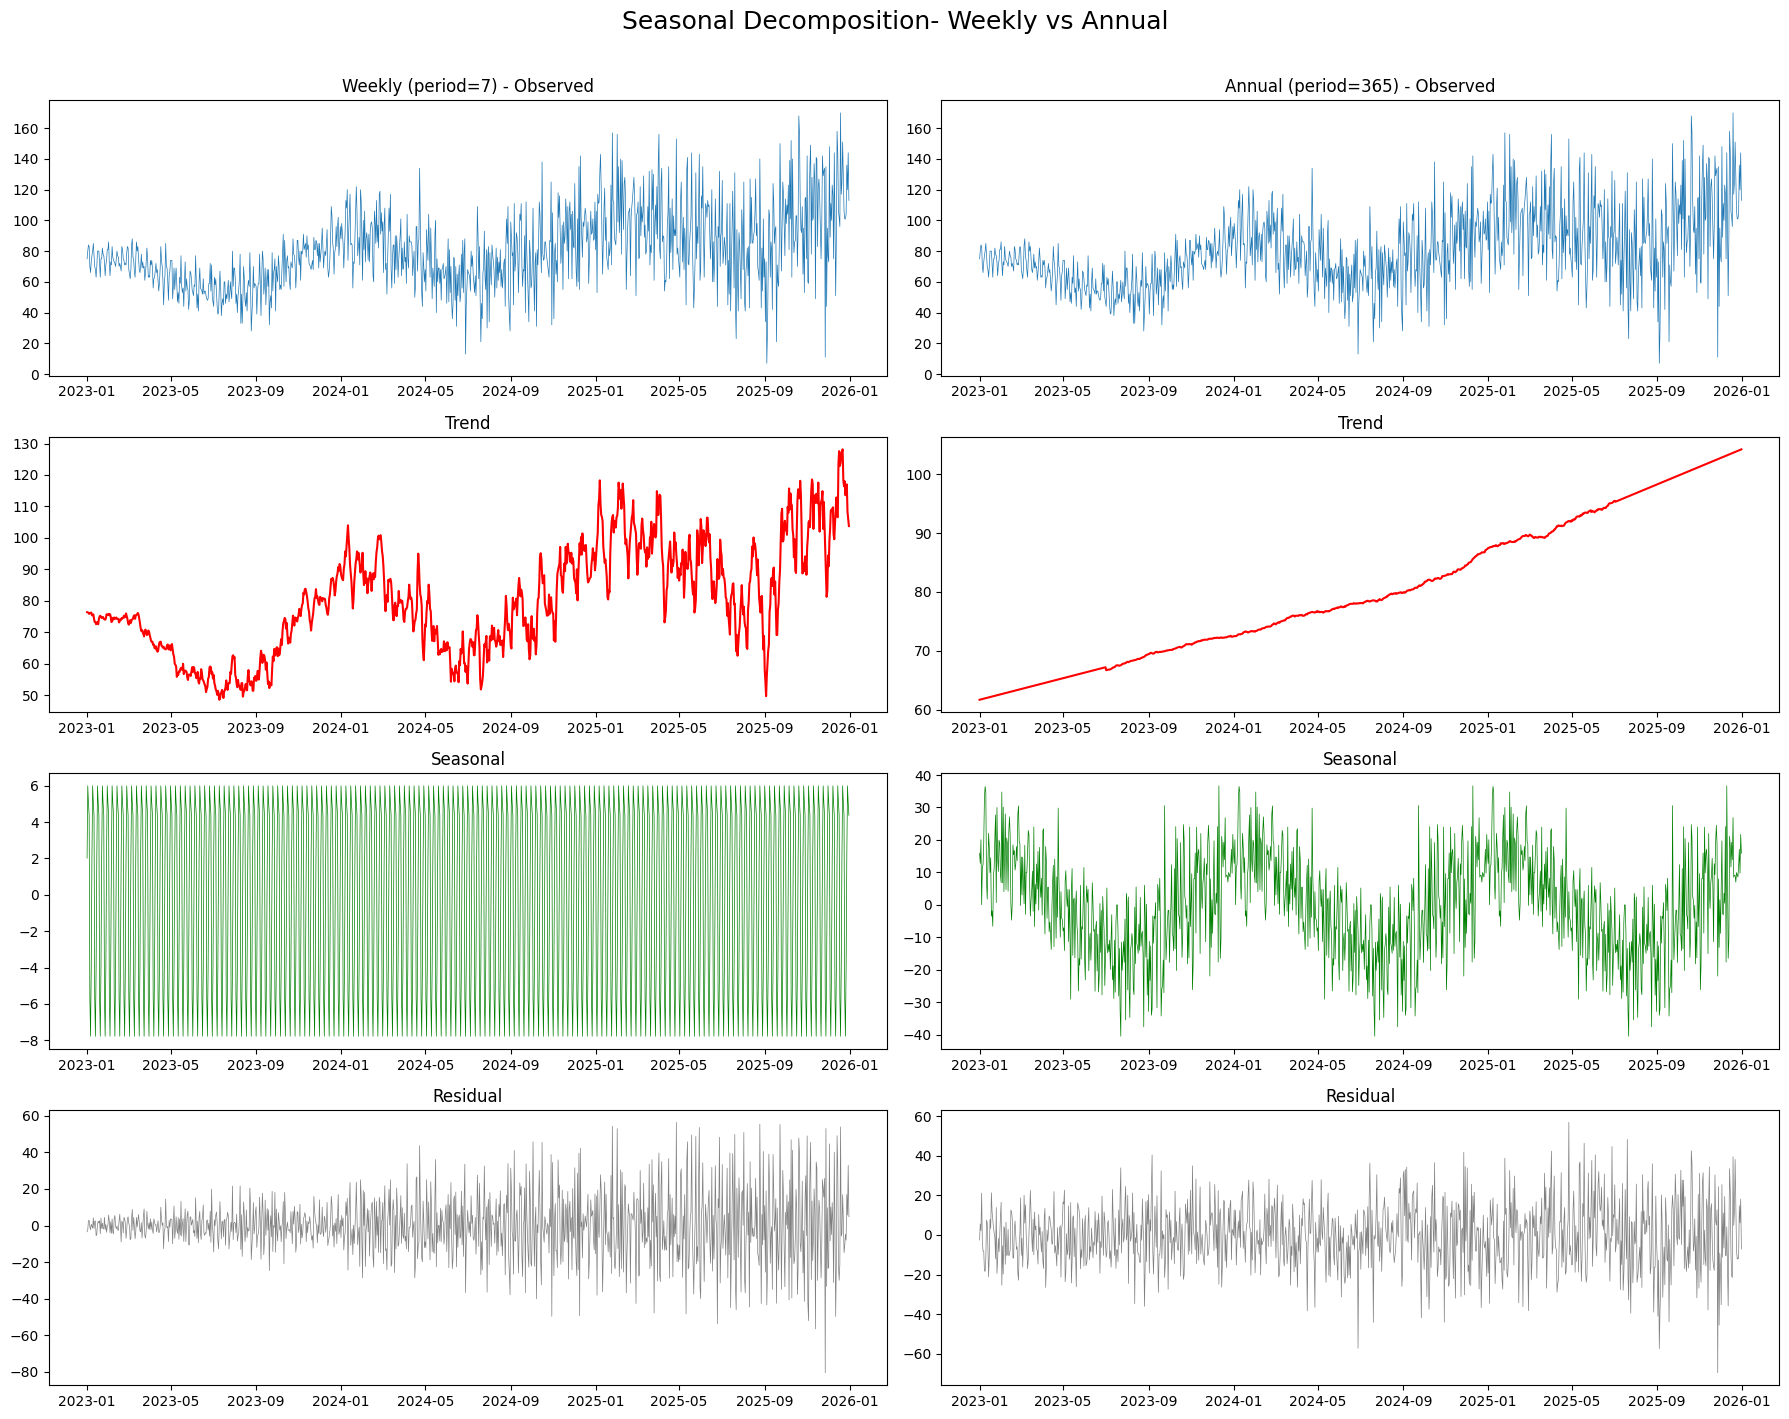

In [13]:
#Seasonal Decomposition (Weekly + Annual)

complaints_ts = df.set_index('date')['complaints']

fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=False)
for col, period, label in [(0, 7, 'Weekly (period=7)'), (1, 365, 'Annual (period=365)')]:
    decomp = seasonal_decompose(complaints_ts, model='additive', period=period, extrapolate_trend='freq')
    axes[0][col].plot(decomp.observed, lw=0.5)
    axes[0][col].set_title(f'{label} - Observed', fontsize=12)
    axes[1][col].plot(decomp.trend, color='red', lw=1.5)
    axes[1][col].set_title('Trend', fontsize=12)
    axes[2][col].plot(decomp.seasonal, color='green', lw=0.5)
    axes[2][col].set_title('Seasonal', fontsize=12)
    axes[3][col].plot(decomp.resid, color='grey', lw=0.5)
    axes[3][col].set_title('Residual', fontsize=12)

plt.suptitle('Seasonal Decomposition- Weekly vs Annual', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## Seasonal Decomposition

The decomposition confirmed three main components in the series:

- A steady upward trend, increasing from around 60 complaints per day in early 2023 to over 100 by the end of 2025  
- Strong annual seasonality, with higher complaint volumes during winter months and lower volumes during summer  
- A weaker but still noticeable weekly pattern, mainly driven by lower weekend activity  

The residual component still showed fairly high variance after removing trend and seasonality, which suggests that day-to-day noise remains one of the main forecasting challenges.

Trend slope: 0.0355 complaints/day (13.0/year)
Trend R-squared: 0.2017


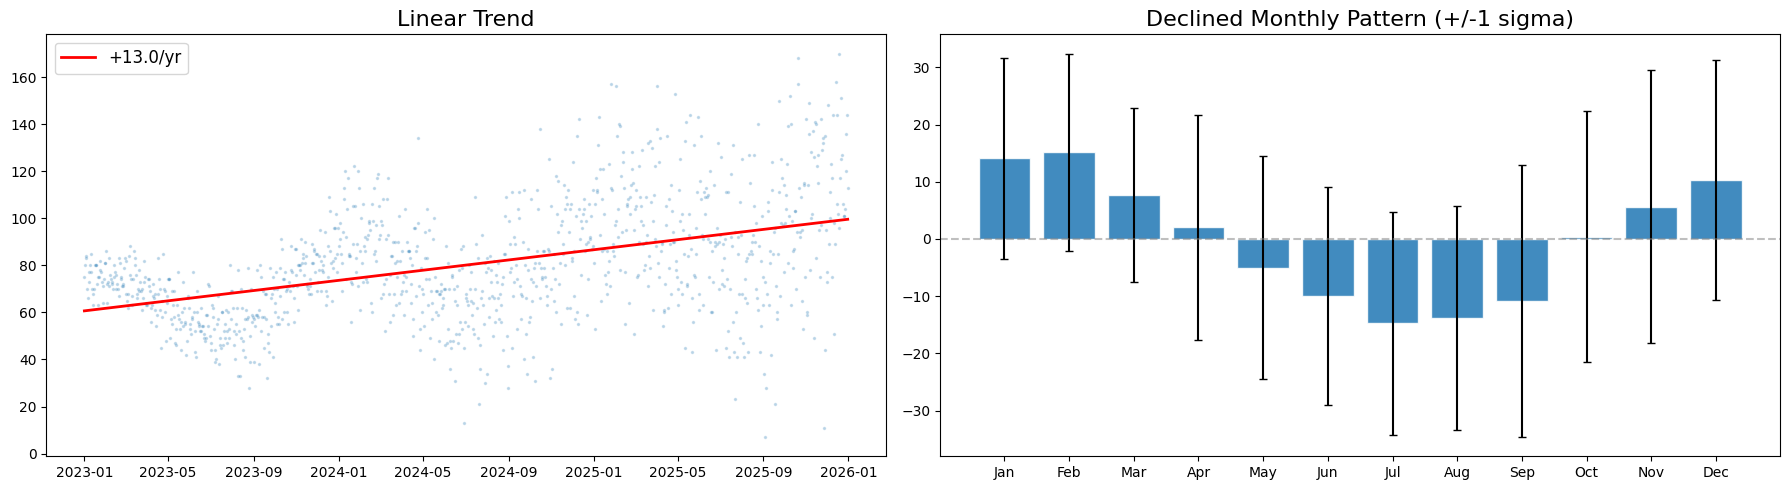

  Month  1:  +14.1 (sigma=17.5)
  Month  2:  +15.2 (sigma=17.2)
  Month  3:   +7.7 (sigma=15.3)
  Month  4:   +2.0 (sigma=19.6)
  Month  5:   -5.0 (sigma=19.5)
  Month  6:  -10.0 (sigma=19.0)
  Month  7:  -14.8 (sigma=19.4)
  Month  8:  -13.8 (sigma=19.6)
  Month  9:  -10.9 (sigma=23.8)
  Month 10:   +0.4 (sigma=22.0)
  Month 11:   +5.7 (sigma=23.9)
  Month 12:  +10.3 (sigma=20.9)


In [14]:
#Trend Quantification
#Linear trend fit and detrended monthly pattern

df['trend_idx'] = (df['date'] - df['date'].min()).dt.days
lr = LinearRegression()
lr.fit(df[['trend_idx']], df['complaints'])
df['trend_pred'] = lr.predict(df[['trend_idx']])
df['detrended'] = df['complaints'] - df['trend_pred']

print(f'Trend slope: {lr.coef_[0]:.4f} complaints/day ({lr.coef_[0]*365:.1f}/year)')
print(f'Trend R-squared: {lr.score(df[["trend_idx"]], df["complaints"]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(df['date'], df['complaints'], '.', alpha=0.2, ms=3, color=color_pal[0])
axes[0].plot(df['date'], df['trend_pred'], '-', lw=2, color='red', label=f'+{lr.coef_[0]*365:.1f}/yr')
axes[0].set_title('Linear Trend', fontsize=16)
axes[0].legend(fontsize=12)

monthly_pattern = df.groupby('month')['detrended'].agg(['mean', 'std'])
axes[1].bar(monthly_pattern.index, monthly_pattern['mean'], yerr=monthly_pattern['std'],
            capsize=3, color=color_pal[0], edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='grey', ls='--', alpha=0.5)
axes[1].set_title('Declined Monthly Pattern (+/-1 sigma)', fontsize=16)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

for m, row in monthly_pattern.iterrows():
    print(f'  Month {m:2d}: {row["mean"]:>+6.1f} (sigma={row["std"]:.1f})')

Lag correlations with target:
lag_7     0.416959
lag_1     0.410360
lag_28    0.405260
lag_14    0.402517
lag_2     0.379042
lag_3     0.342193
Name: complaints, dtype: float64


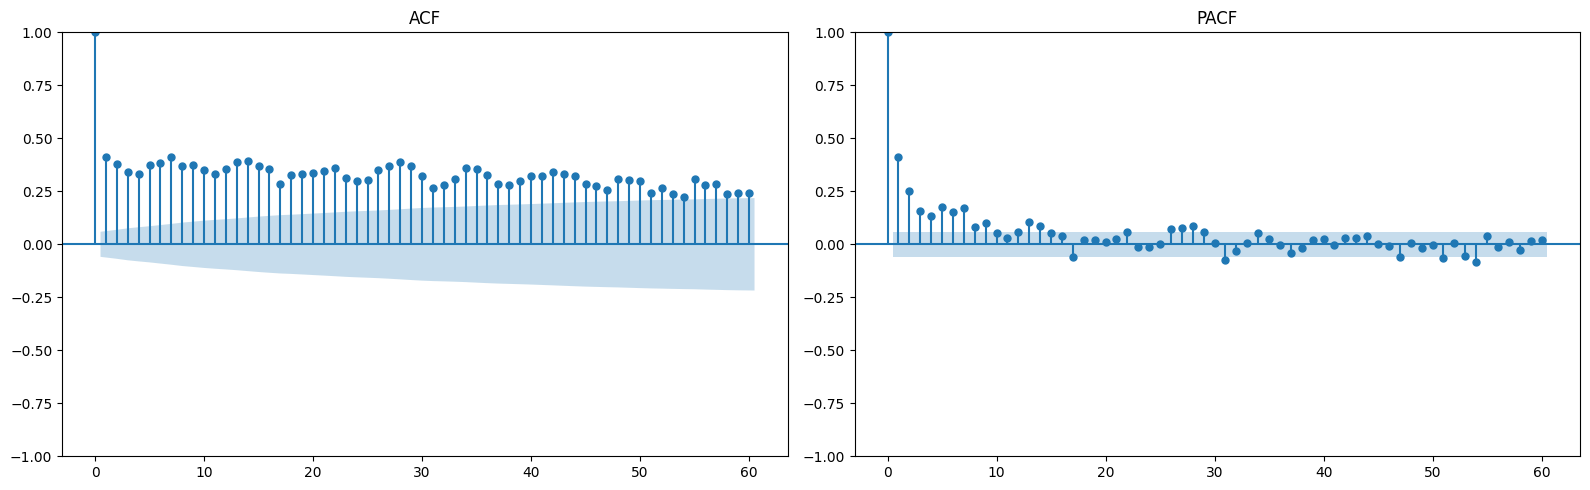

In [15]:
#Create lag features
lag_days = [1, 2, 3, 7, 14, 28]
for lag in lag_days:
    df[f'lag_{lag}'] = df['complaints'].shift(lag)

lag_cols = [f'lag_{l}' for l in lag_days]
lag_corrs = df[lag_cols + ['complaints']].corr()['complaints'][:-1].sort_values(ascending=False)
print('Lag correlations with target:')
print(lag_corrs)

#ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['complaints'].dropna(), lags=60, ax=axes[0], title='ACF')
plot_pacf(df['complaints'].dropna(), lags=60, ax=axes[1], title='PACF')
plt.tight_layout()
plt.show()

## Lag Feature Analysis

Lag relationships were weaker than expected.

- Most lag correlations stayed below 0.35  
- The ACF showed a slow decay, mainly reflecting the long-term trend  
- The PACF dropped off quickly, suggesting behaviour closer to an AR(1)-style process with trend rather than strong repeating autoregressive structure  

Because of this, recursive multi-step forecasting with heavy lag dependence introduced noticeable error accumulation over longer horizons.


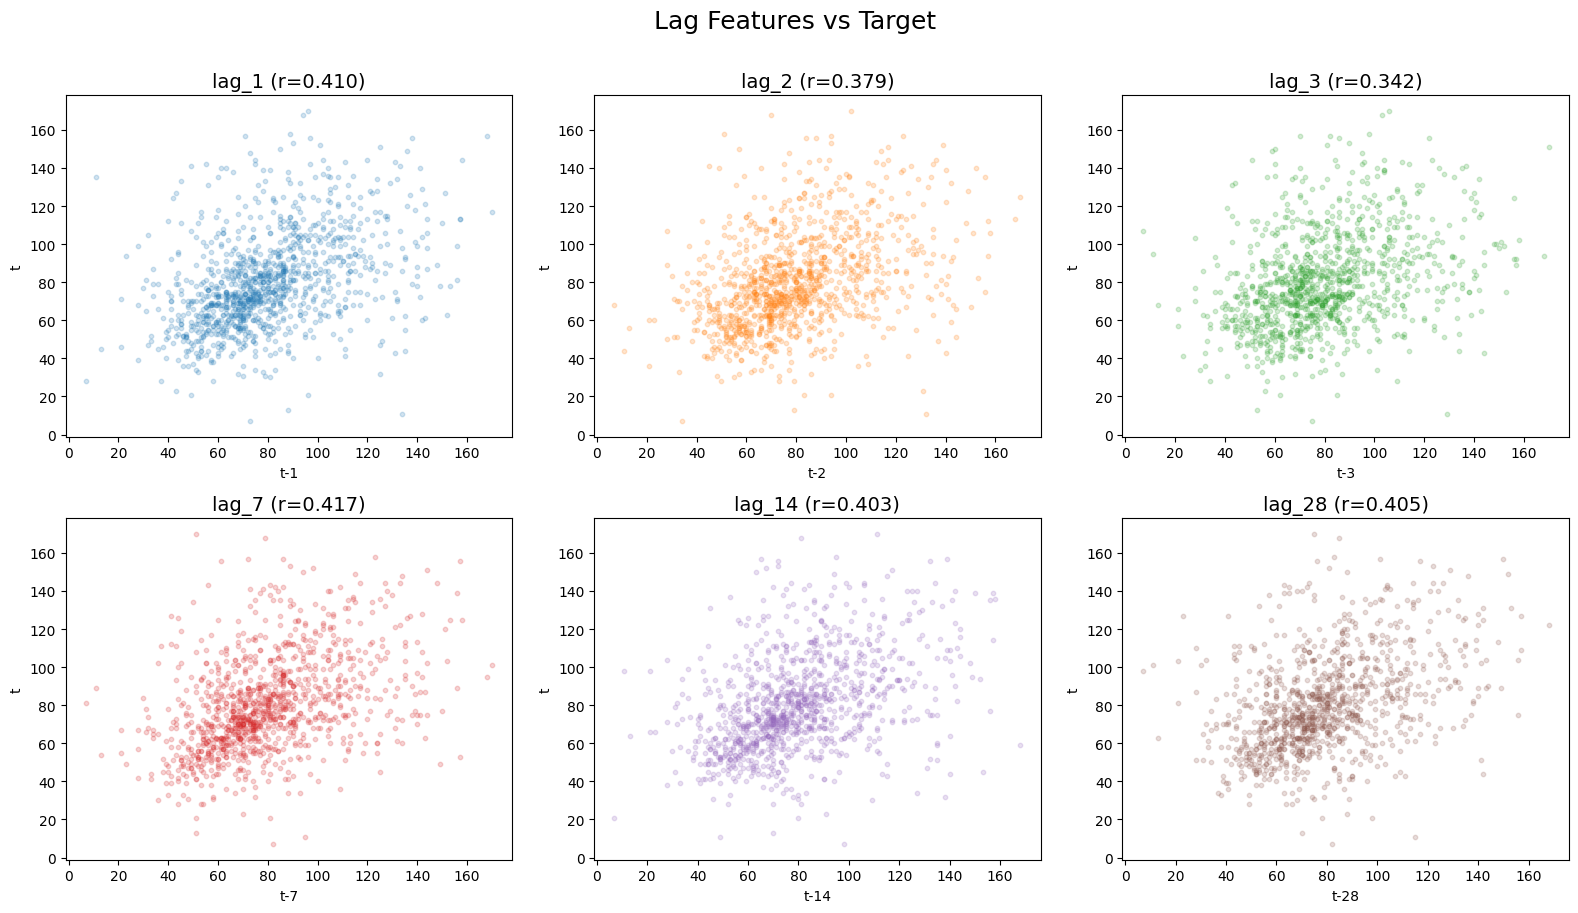

In [16]:
#Lag scatter plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, lag in enumerate(lag_days):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[f'lag_{lag}'], df['complaints'], alpha=0.2, s=10, color=color_pal[i])
    r = df[f'lag_{lag}'].corr(df['complaints'])
    ax.set_title(f'lag_{lag} (r={r:.3f})', fontsize=14)
    ax.set_xlabel(f't-{lag}'); ax.set_ylabel('t')
plt.suptitle('Lag Features vs Target', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

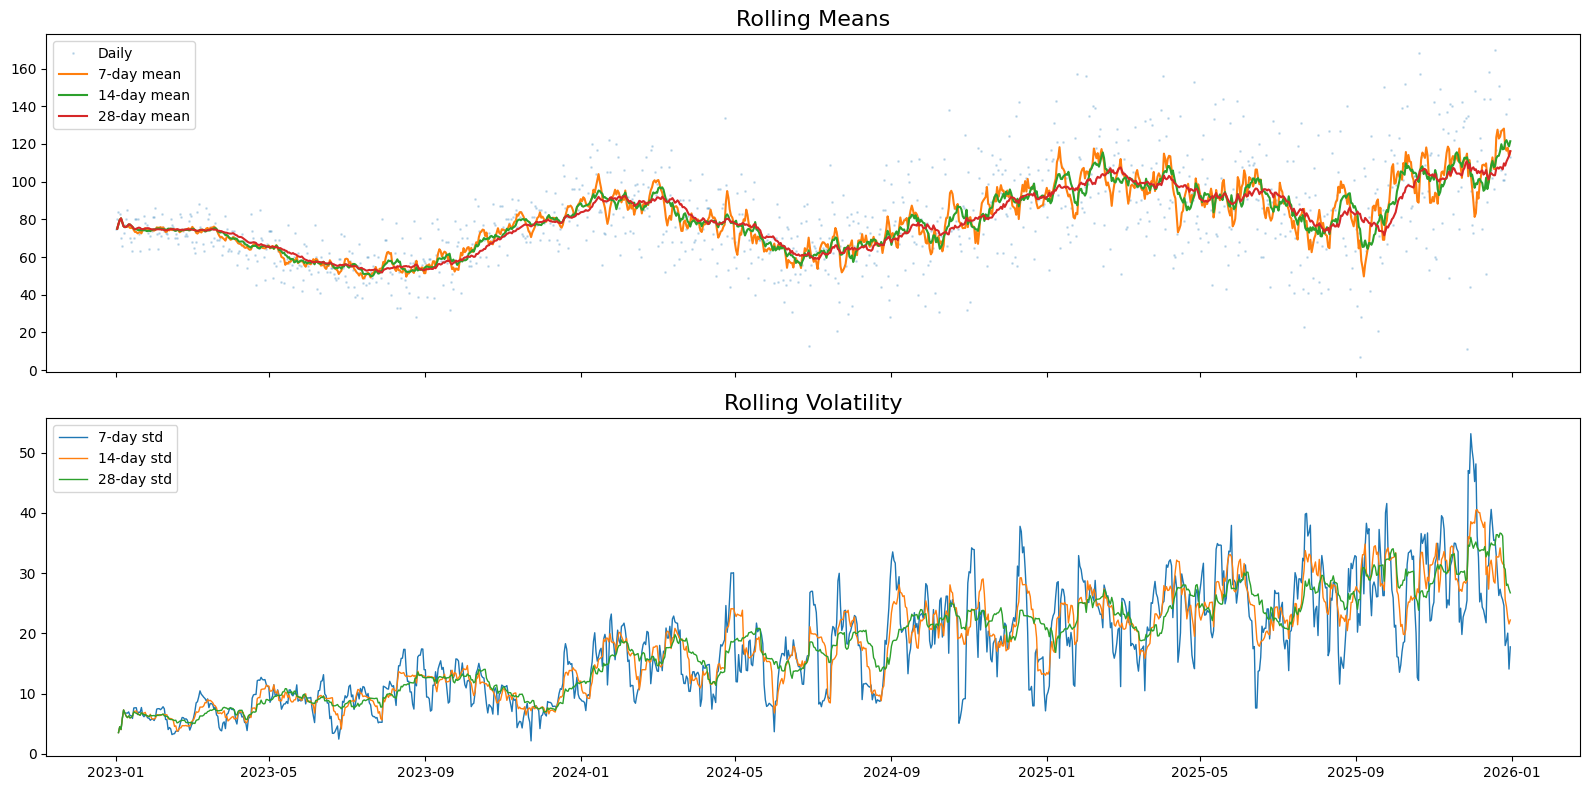

In [17]:
#Rolling Window Features

windows = [7, 14, 28]
for w in windows:
    rolled = df['complaints'].shift(1).rolling(w, min_periods=1)
    df[f'roll_mean_{w}'] = rolled.mean()
    df[f'roll_std_{w}'] = rolled.std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(df['date'], df['complaints'], '.', alpha=0.2, ms=2, label='Daily')
for w in windows:
    axes[0].plot(df['date'], df[f'roll_mean_{w}'], lw=1.5, label=f'{w}-day mean')
axes[0].set_title('Rolling Means', fontsize=16)
axes[0].legend()

for w in windows:
    axes[1].plot(df['date'], df[f'roll_std_{w}'], lw=1, label=f'{w}-day std')
axes[1].set_title('Rolling Volatility', fontsize=16)
axes[1].legend()
plt.tight_layout()
plt.show()

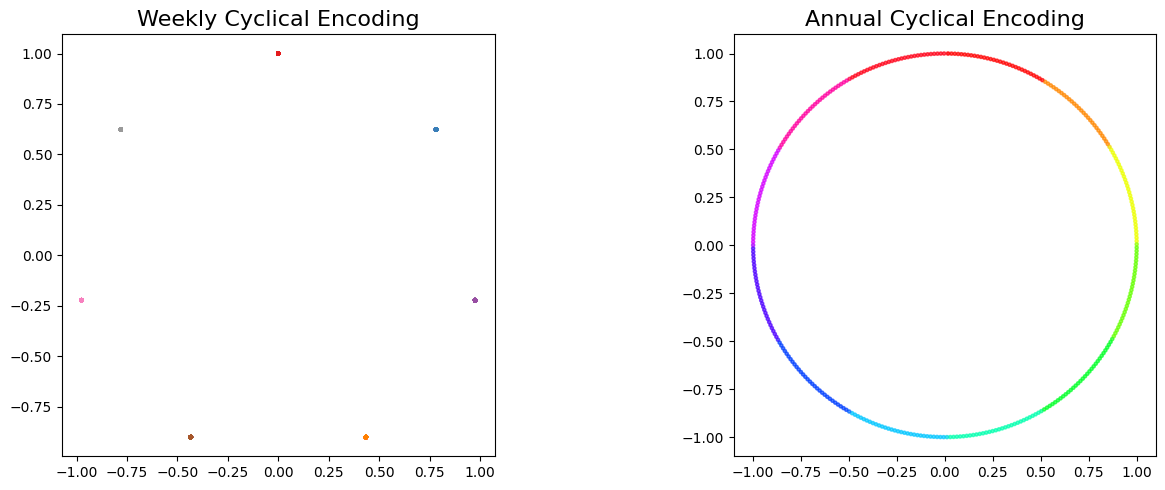

In [18]:
#Cyclical Encoding - Sin/Cos Fourier Features

#Weekly period (k=1,2)
for k in [1, 2]:
    df[f'week_sin_{k}'] = np.sin(2 * np.pi * k * df['day_of_week'] / 7)
    df[f'week_cos_{k}'] = np.cos(2 * np.pi * k * df['day_of_week'] / 7)

#Annual period (k=1,2,3)
for k in [1, 2, 3]:
    df[f'year_sin_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'year_cos_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['week_sin_1'], df['week_cos_1'], c=df['day_of_week'], cmap='Set1', alpha=0.3, s=5)
axes[0].set_title('Weekly Cyclical Encoding', fontsize=16)
axes[0].set_aspect('equal')
axes[1].scatter(df['year_sin_1'], df['year_cos_1'], c=df['month'], cmap='hsv', alpha=0.3, s=5)
axes[1].set_title('Annual Cyclical Encoding', fontsize=16)
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

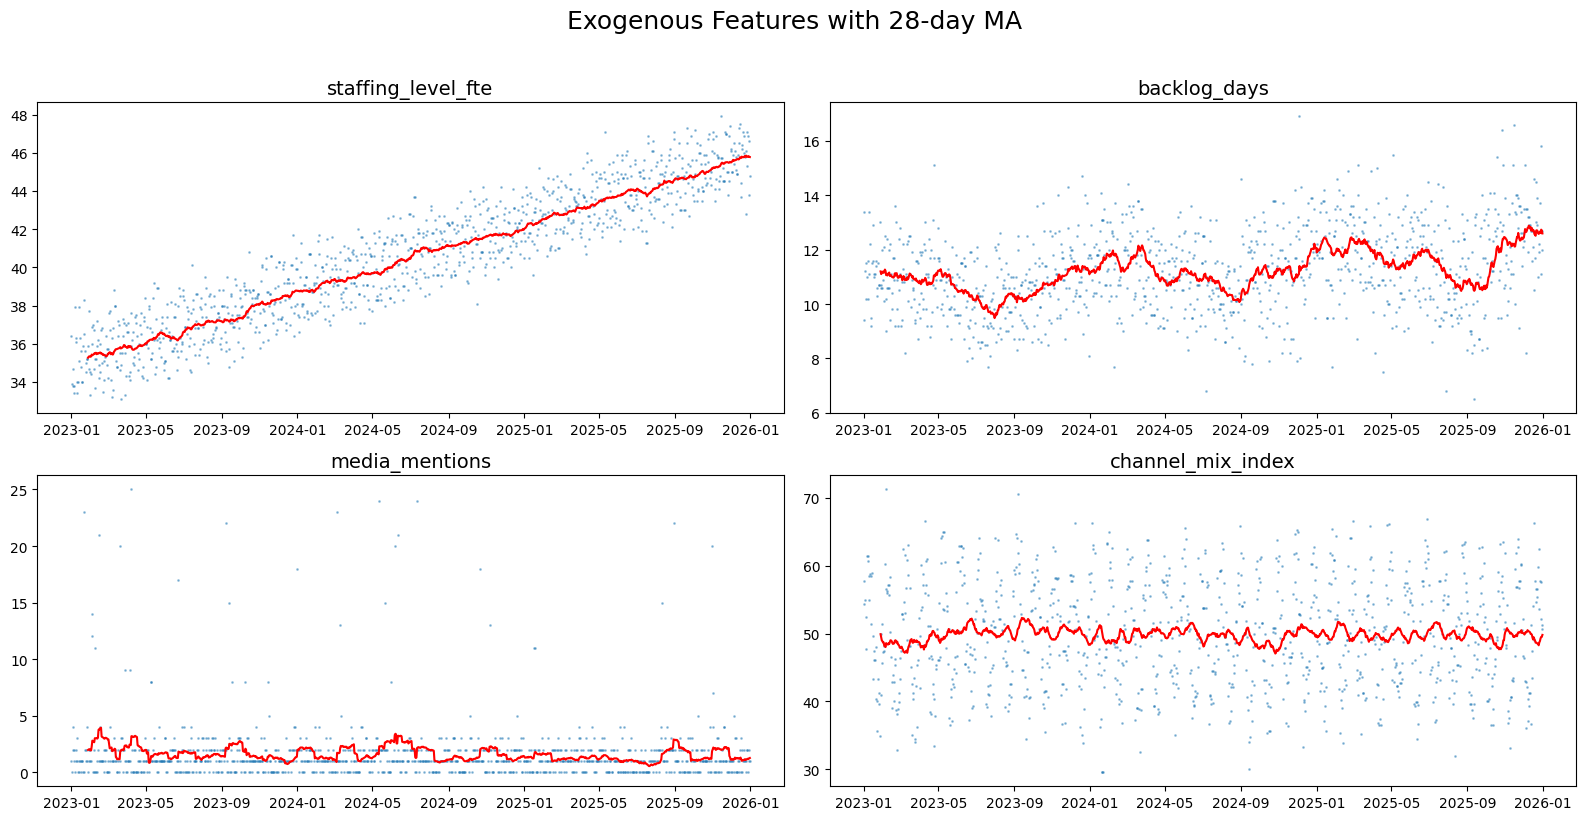

IQR: 31.0, Bounds: [16.5, 140.5]
Outlier days: 27 (2.5%)


In [19]:
#Exogenous features over time
exog_cols = ['staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index']
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for i, col in enumerate(exog_cols):
    ax = axes[i // 2][i % 2]
    ax.plot(df['date'], df[col], '.', alpha=0.4, ms=2)
    ax.plot(df['date'], df[col].rolling(28).mean(), lw=1.5, color='red')
    ax.set_title(col, fontsize=14)
plt.suptitle('Exogenous Features with 28-day MA', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

#Outlier detection (IQR)
Q1 = df['complaints'].quantile(0.25)
Q3 = df['complaints'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['complaints'] < Q1 - 1.5 * IQR) | (df['complaints'] > Q3 + 1.5 * IQR)]
print(f'IQR: {IQR:.1f}, Bounds: [{Q1 - 1.5 * IQR:.1f}, {Q3 + 1.5 * IQR:.1f}]')
print(f'Outlier days: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

In [20]:
#Linear trend projection (extrapolatable into forecast period)
df['trend_linear'] = lr.predict(df[['trend_idx']])

#Define feature sets
exclude_cols = {'date', 'complaints', 'row_id', 'centered_7d_mean', 'trend_pred', 'detrended', 'year'}
all_features = [c for c in df.columns if c not in exclude_cols]
no_lag_features = [c for c in all_features if not c.startswith('lag_') and not c.startswith('roll_')]

print(f'All features ({len(all_features)}): {all_features}')
print(f'No-lag features ({len(no_lag_features)}): {no_lag_features}')

#Drop burn-in rows (first 28 days have NaN lags)
valid_mask = df[all_features].notna().all(axis=1) & df['complaints'].notna()
df_valid = df[valid_mask].reset_index(drop=True)
print(f'\nValid observations after lag burn-in: {len(df_valid)}')

All features (36): ['is_weekend', 'bank_holiday_flag', 'staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'trend_idx', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28', 'week_sin_1', 'week_cos_1', 'week_sin_2', 'week_cos_2', 'year_sin_1', 'year_cos_1', 'year_sin_2', 'year_cos_2', 'year_sin_3', 'year_cos_3', 'trend_linear']
No-lag features (24): ['is_weekend', 'bank_holiday_flag', 'staffing_level_fte', 'backlog_days', 'media_mentions', 'channel_mix_index', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'trend_idx', 'week_sin_1', 'week_cos_1', 'week_sin_2', 'week_cos_2', 'year_sin_1', 'year_cos_1', 'year_sin_2', 'year_cos_2', 'year_sin_3', 'year_cos_3', 'trend_linear']

Valid observations after lag burn-in: 1068


In [21]:
#Ceoss Validation splits
def ts_cv_splits(n_samples, n_splits=5, test_size=90):
    min_train = max(180, n_samples - n_splits * test_size)
    step = (n_samples - min_train - test_size) // max(n_splits - 1, 1)
    splits = []
    for i in range(n_splits):
        train_end = min_train + i * step
        test_end = min(train_end + test_size, n_samples)
        if test_end <= train_end:
            break
        splits.append((np.arange(0, train_end), np.arange(train_end, test_end)))
    return splits

#Evaluation metrics
def compute_metrics(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    yt, yp = y_true[mask], y_pred[mask]
    return {
        'MAE': round(mean_absolute_error(yt, yp), 2),
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 2),
        'MdAE': round(median_absolute_error(yt, yp), 2),
        'MAPE': round(mean_absolute_percentage_error(yt, yp) * 100, 2),
        'R2': round(r2_score(yt, yp), 4),
    }

splits = ts_cv_splits(len(df_valid))
print(f'CV Splits: {len(splits)} folds')
for i, (tr, te) in enumerate(splits):
    print(f'  Fold {i+1}: train={len(tr)}, test={len(te)}, '
          f'{df_valid.iloc[te[0]]["date"].date()} to {df_valid.iloc[te[-1]]["date"].date()}')

CV Splits: 5 folds
  Fold 1: train=618, test=90, 2024-10-08 to 2025-01-05
  Fold 2: train=708, test=90, 2025-01-06 to 2025-04-05
  Fold 3: train=798, test=90, 2025-04-06 to 2025-07-04
  Fold 4: train=888, test=90, 2025-07-05 to 2025-10-02
  Fold 5: train=978, test=90, 2025-10-03 to 2025-12-31


In [22]:
y = df_valid['complaints']

model_specs = {
    'Ridge (no-lag)':  (lambda: Ridge(alpha=1.0), no_lag_features),
    'Ridge (all)':     (lambda: Ridge(alpha=1.0), all_features),
    'LGBM (no-lag)':   (lambda: lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=20,
        subsample=0.75, colsample_bytree=0.7, min_child_samples=15,
        reg_alpha=0.5, reg_lambda=3.0, objective='regression_l1',
        verbose=-1, random_state=42), no_lag_features),
    'LGBM (all)':      (lambda: lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=20,
        subsample=0.75, colsample_bytree=0.7, min_child_samples=15,
        reg_alpha=0.5, reg_lambda=3.0, objective='regression_l1',
        verbose=-1, random_state=42), all_features),
    'HistGB (no-lag)': (lambda: HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.03, max_depth=5, max_leaf_nodes=20,
        min_samples_leaf=15, l2_regularization=3.0, random_state=42), no_lag_features),
    'HistGB (all)':    (lambda: HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.03, max_depth=5, max_leaf_nodes=20,
        min_samples_leaf=15, l2_regularization=3.0, random_state=42), all_features),
}

results = {name: [] for name in model_specs}

for fold_i, (train_idx, test_idx) in enumerate(splits):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(f'Fold {fold_i + 1}:')
    for name, (model_fn, cols) in model_specs.items():
        m = model_fn()
        m.fit(df_valid.iloc[train_idx][cols], y_train)
        preds = np.clip(np.round(m.predict(df_valid.iloc[test_idx][cols])), 0, None)
        metrics = compute_metrics(y_test.values, preds)
        results[name].append(metrics)
        print(f'  {name:<18s} MAE={metrics["MAE"]:>6.2f}  RMSE={metrics["RMSE"]:>6.2f}  R2={metrics["R2"]:>7.4f}')
    print()

Fold 1:
  Ridge (no-lag)     MAE= 16.34  RMSE= 21.51  R2= 0.0403
  Ridge (all)        MAE= 17.02  RMSE= 22.09  R2=-0.0127
  LGBM (no-lag)      MAE= 18.97  RMSE= 23.73  R2=-0.1686
  LGBM (all)         MAE= 18.46  RMSE= 23.43  R2=-0.1388
  HistGB (no-lag)    MAE= 17.99  RMSE= 22.68  R2=-0.0676
  HistGB (all)       MAE= 18.66  RMSE= 23.00  R2=-0.0975

Fold 2:
  Ridge (no-lag)     MAE= 18.77  RMSE= 23.63  R2=-0.0149
  Ridge (all)        MAE= 19.08  RMSE= 24.05  R2=-0.0520
  LGBM (no-lag)      MAE= 21.51  RMSE= 27.00  R2=-0.3255
  LGBM (all)         MAE= 23.23  RMSE= 29.42  R2=-0.5738
  HistGB (no-lag)    MAE= 22.44  RMSE= 28.00  R2=-0.4252
  HistGB (all)       MAE= 25.47  RMSE= 32.19  R2=-0.8846

Fold 3:
  Ridge (no-lag)     MAE= 21.00  RMSE= 26.26  R2=-0.1282
  Ridge (all)        MAE= 21.38  RMSE= 26.92  R2=-0.1856
  LGBM (no-lag)      MAE= 20.78  RMSE= 25.73  R2=-0.0829
  LGBM (all)         MAE= 20.06  RMSE= 24.41  R2= 0.0250
  HistGB (no-lag)    MAE= 22.88  RMSE= 28.50  R2=-0.3290
  His

AVERAGE CV METRICS, 5-fold, 90-day windows
                   MAE   RMSE  MdAE   MAPE    R2
Model                                           
Ridge (no-lag)   20.58  26.02  16.0  29.36 -0.02
Ridge (all)      21.01  26.50  17.4  29.89 -0.06
LGBM (no-lag)    22.60  28.17  19.0  30.82 -0.19
LGBM (all)       22.77  28.36  19.4  30.66 -0.22
HistGB (no-lag)  23.73  29.55  19.3  33.31 -0.31
HistGB (all)     24.45  30.37  20.7  33.75 -0.39

Best model: Ridge (no-lag) (MAE=20.58)


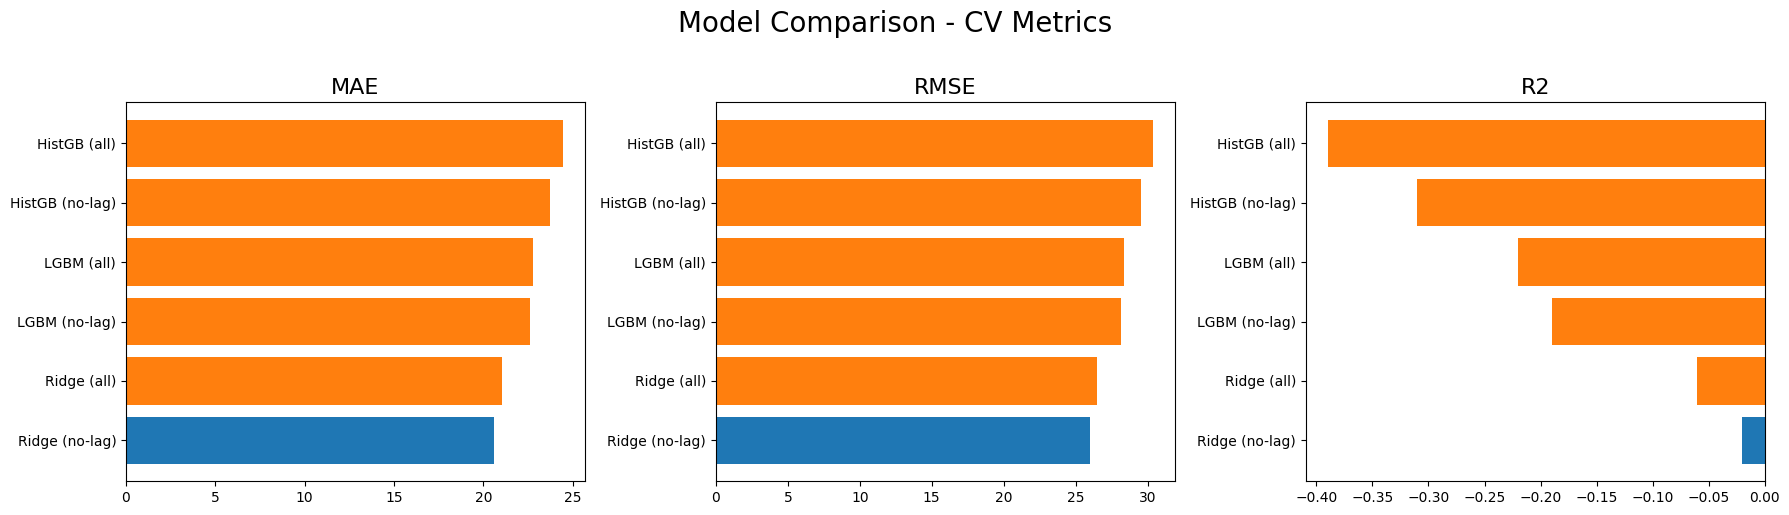

In [23]:
#Average Cross Validation Results
print('AVERAGE CV METRICS, 5-fold, 90-day windows')

summary_rows = []
for name, folds in results.items():
    avg = {k: round(np.mean([f[k] for f in folds]), 2) for k in folds[0]}
    summary_rows.append({'Model': name, **avg})

summary_df = pd.DataFrame(summary_rows).set_index('Model').sort_values('MAE')
print(summary_df.to_string())
print(f'\nBest model: {summary_df.index[0]} (MAE={summary_df.iloc[0]["MAE"]})')

#Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    ax = axes[i]
    vals = summary_df[metric].sort_values(ascending=(metric != 'R2'))
    best = vals.min() if metric != 'R2' else vals.max()
    colors = [color_pal[0] if v == best else color_pal[1] for v in vals.values]
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(metric, fontsize=16)
plt.suptitle('Model Comparison - CV Metrics', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

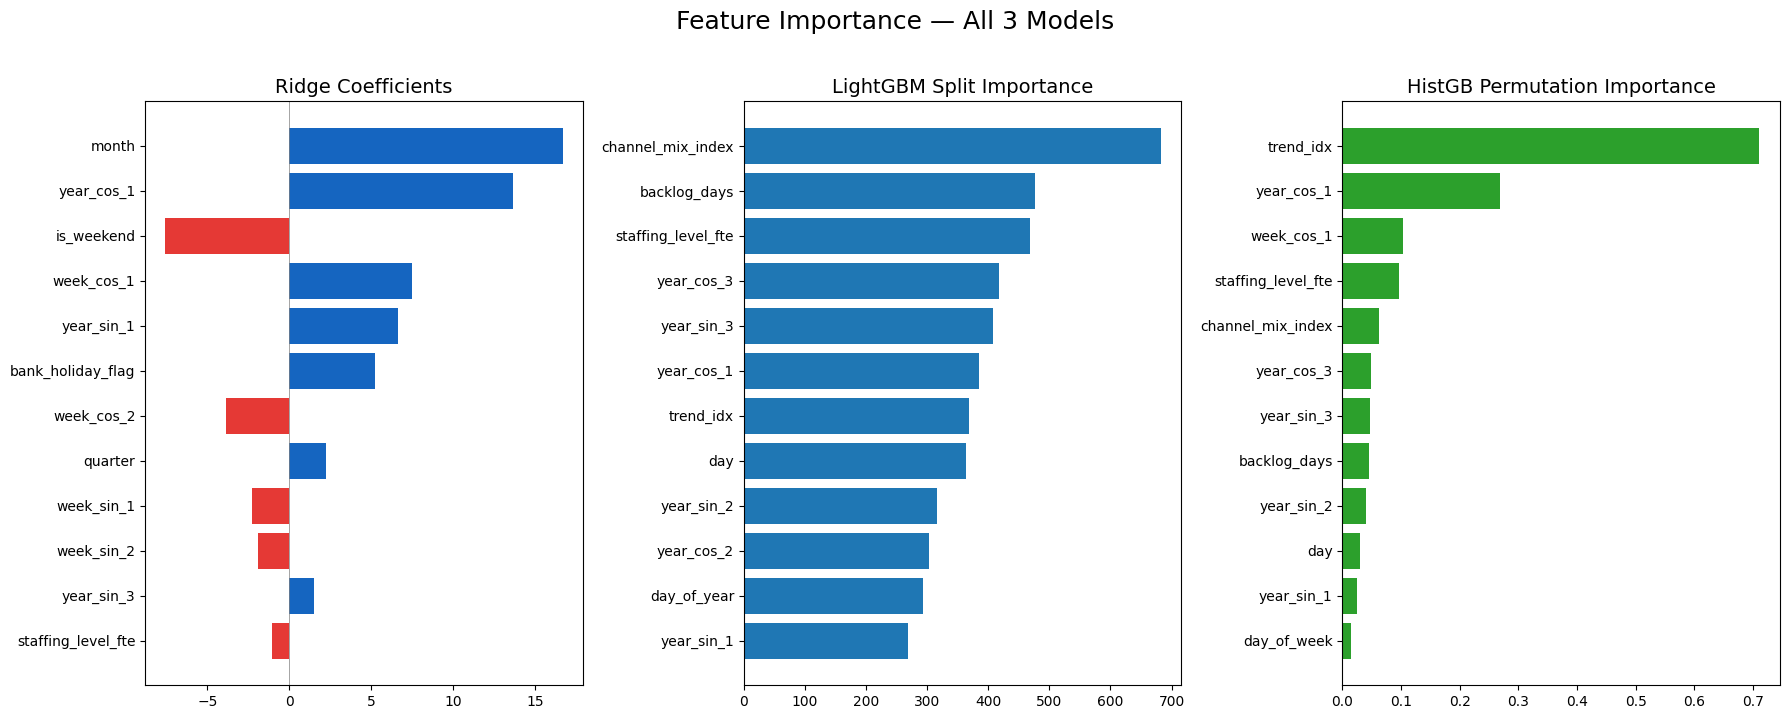

In [24]:
X_nlag = df_valid[no_lag_features]
y_all = df_valid['complaints']

#Ridge coefficients
ridge = Ridge(alpha=1.0)
ridge.fit(X_nlag, y_all)
ridge_coefs = pd.Series(ridge.coef_, index=no_lag_features).sort_values(key=abs, ascending=False)

#LightGBM split importance
lgbm_model = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.03, max_depth=5, num_leaves=20,
    subsample=0.75, colsample_bytree=0.7, min_child_samples=15,
    reg_alpha=0.5, reg_lambda=3.0, objective='regression_l1', verbose=-1, random_state=42)
lgbm_model.fit(X_nlag, y_all)
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=no_lag_features).sort_values(ascending=False)

#HistGB permutation importance
histgb_model = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.03, max_depth=5, max_leaf_nodes=20,
    min_samples_leaf=15, l2_regularization=3.0, random_state=42)
histgb_model.fit(X_nlag, y_all)
perm = permutation_importance(histgb_model, X_nlag, y_all, n_repeats=10, random_state=42)
histgb_imp = pd.Series(perm.importances_mean, index=no_lag_features).sort_values(ascending=False)

#Plot all 3
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
top_n = 12

top = ridge_coefs.head(top_n)
colors = ['#E53935' if v < 0 else '#1565C0' for v in top.values]
axes[0].barh(top.index[::-1], top.values[::-1], color=colors[::-1])
axes[0].set_title('Ridge Coefficients', fontsize=14)
axes[0].axvline(0, color='grey', lw=0.5)

top = lgbm_imp.head(top_n)
axes[1].barh(top.index[::-1], top.values[::-1], color=color_pal[0])
axes[1].set_title('LightGBM Split Importance', fontsize=14)

top = histgb_imp.head(top_n)
axes[2].barh(top.index[::-1], top.values[::-1], color=color_pal[2])
axes[2].set_title('HistGB Permutation Importance', fontsize=14)

plt.suptitle('Feature Importance — All 3 Models', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
print('Best model: Ridge (no-lag)')
print(f'MAE: {summary_df.iloc[0]["MAE"]}')
print(f'RMSE: {summary_df.iloc[0]["RMSE"]}')
print(f'R2: {summary_df.iloc[0]["R2"]}')
print(f'\nTotal features used: {len(no_lag_features)}')

Best model: Ridge (no-lag)
MAE: 20.58
RMSE: 26.02
R2: -0.02

Total features used: 24
